---
format: 
    html: 
        embed-resources: true
--- 

# Emotion Classifier by Theon

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import random

random.seed(1)

## RAVDESS

In [2]:
RAVDESS = './data/RAVDESS'
ravdess_directory_list = os.listdir(RAVDESS)
type = []
actor_list = []
path_list = []
gender_list = []
emotion_list = []

code_to_emotion = {
    '03' : 'happy',
    '01' : 'neutral',
    '04' : 'sad',
    '05' : 'angry',
    '06' : 'fear',
    '07' : 'disgust',
}

for directory in ravdess_directory_list:
    actor_files = os.listdir(os.path.join(RAVDESS, directory))
    for audio_file in actor_files: 
        part = audio_file.split('.')[0]
        code = part.split('-')[2]
        if code in code_to_emotion:
            gender_code = int(part.split('-')[6])
            type.append('RAVDESS')
            actor_list.append(directory)
            path_list.append(f"{RAVDESS}{directory}/{audio_file}")
            gender_list.append('female' if gender_code & 1 == 0 else 'male')
            emotion_list.append(code_to_emotion[code])
        
            
ravdess = pd.concat([
    pd.DataFrame(type, columns=['type']),
    pd.DataFrame(actor_list, columns=['actor']),
    pd.DataFrame(path_list, columns=['path']),
    pd.DataFrame(gender_list, columns=['sex']),
    pd.DataFrame(emotion_list, columns=['emotion'])
], axis=1)

# ravdess = ravdess[ravdess["sex"] == 'female']
ravdess.head()

,type,actor,path,sex,emotion
0,RAVDESS,Actor_01,./data/RAVDESSActor_01/03-01-01-01-01-01-01.wav,male,neutral
1,RAVDESS,Actor_01,./data/RAVDESSActor_01/03-01-01-01-01-02-01.wav,male,neutral
2,RAVDESS,Actor_01,./data/RAVDESSActor_01/03-01-01-01-02-01-01.wav,male,neutral
3,RAVDESS,Actor_01,./data/RAVDESSActor_01/03-01-01-01-02-02-01.wav,male,neutral
4,RAVDESS,Actor_01,./data/RAVDESSActor_01/03-01-03-01-01-01-01.wav,male,happy


In [ ]:
# Map emotion names to same numeric labels
RAVDESS_EMOTION_MAP = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5
}

ravdess = ravdess[ravdess["emotion"].isin(RAVDESS_EMOTION_MAP.keys())]

ravdess["label"] = ravdess["emotion"].map(RAVDESS_EMOTION_MAP)

# Rename columns
ravdess = ravdess.rename(columns={"path": "file"})

# IMPORTANT: Fix path formatting
ravdess["file"] = ravdess["file"].apply(lambda x: x.replace("./data/RAVDESS", "./data/RAVDESS/"))

print(ravdess.head())
print(ravdess["label"].value_counts())
print(ravdess["sex"].value_counts())

      type     actor                                              file   sex  \
0  RAVDESS  Actor_01  ./data/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav  male   
1  RAVDESS  Actor_01  ./data/RAVDESS/Actor_01/03-01-01-01-01-02-01.wav  male   
2  RAVDESS  Actor_01  ./data/RAVDESS/Actor_01/03-01-01-01-02-01-01.wav  male   
3  RAVDESS  Actor_01  ./data/RAVDESS/Actor_01/03-01-01-01-02-02-01.wav  male   
4  RAVDESS  Actor_01  ./data/RAVDESS/Actor_01/03-01-03-01-01-01-01.wav  male   

   emotion  label  
0  neutral      4  
1  neutral      4  
2  neutral      4  
3  neutral      4  
4    happy      3  
label
3    192
5    192
0    192
2    192
1    192
4     96
Name: count, dtype: int64
sex
male      528
female    528
Name: count, dtype: int64


## Crema-D

In [4]:
female_id_set = {
    '1002','1003','1004','1006','1007','1008','1009','1010','1012','1013',
    '1018','1020','1021','1024','1025','1028','1029','1030','1037','1043',
    '1046','1047','1049','1052','1053','1054','1055','1056','1058','1060',
    '1061','1063','1072','1073','1074','1075','1076','1078','1079','1082',
    '1084','1089','1091'
}

In [5]:
# 6-class emotion mapping
EMOTION_MAP = {
    'ANG': 0,
    'DIS': 1,
    'FEA': 2,
    'HAP': 3,
    'NEU': 4,
    'SAD': 5
}

audio_dir = "./data/AudioWAV/"

files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]

data = []

for f in files:
    parts = f.split("_")
    actor_id = parts[0]
    emotion = parts[2]
    type = 'AudioWAV'

    # Mark sex
    if actor_id not in female_id_set:
        sex = 'female'
    else:
        sex = 'male'

    # # Only keep female
    # if actor_id not in female_id_set:
    #     continue
    
    if emotion not in EMOTION_MAP:
        continue
    
    emotion_label = EMOTION_MAP[emotion]
    
    data.append({
        "type": type,
        "file": os.path.join(audio_dir, f),
        "actor": actor_id,
        "sex": sex,
        "emotion": emotion,
        "label": emotion_label
    })

df = pd.DataFrame(data)
print(df.head())
print(df["label"].value_counts())
print(df["sex"].value_counts())

       type                                 file actor     sex emotion  label
0  AudioWAV  ./data/AudioWAV/1001_DFA_ANG_XX.wav  1001  female     ANG      0
1  AudioWAV  ./data/AudioWAV/1001_DFA_DIS_XX.wav  1001  female     DIS      1
2  AudioWAV  ./data/AudioWAV/1001_DFA_FEA_XX.wav  1001  female     FEA      2
3  AudioWAV  ./data/AudioWAV/1001_DFA_HAP_XX.wav  1001  female     HAP      3
4  AudioWAV  ./data/AudioWAV/1001_DFA_NEU_XX.wav  1001  female     NEU      4
label
0    1271
1    1271
2    1271
3    1271
5    1271
4    1087
Name: count, dtype: int64
sex
female    3930
male      3512
Name: count, dtype: int64


## Tess

In [6]:
TESS = './data/TESS/'
tess_dir_list = os.listdir(TESS)
type = []
actor_list = []
path_list = []
gender_list = []
emotion_list = [] 

code_to_emotion = {
    'happy'   : 'happy',
    'neutral' : 'neutral',
    'sad'     : 'sad',
    'Sad'     : 'sad',
    'angry'   : 'angry',
    'fear'    : 'fear',
    'disgust' : 'disgust',
}

for directory in tess_dir_list:
    audio_files = os.listdir(os.path.join(TESS, directory))
    for audio_file in audio_files:
        part = audio_file.split('.')[0]
        actor = directory.split('_')[0]
        code = part.split('_')[2]
        if code in code_to_emotion:
            type.append('TESS')
            actor_list.append(actor)
            path_list.append(f"{TESS}{directory}/{audio_file}") 
            gender_list.append('female') # female only dataset
            emotion_list.append(code_to_emotion[code])
            
tess = pd.concat([
    pd.DataFrame(type, columns=['type']),
    pd.DataFrame(actor_list, columns=['actor']),
    pd.DataFrame(path_list, columns=['path']),
    pd.DataFrame(gender_list, columns=['sex']),
    pd.DataFrame(emotion_list, columns=['emotion'])
], axis=1)

# tess = tess[tess["sex"] == 'female']
tess.head()

,type,actor,path,sex,emotion
0,TESS,OAF,./data/TESS/OAF_angry/OAF_back_angry.wav,female,angry
1,TESS,OAF,./data/TESS/OAF_angry/OAF_bar_angry.wav,female,angry
2,TESS,OAF,./data/TESS/OAF_angry/OAF_base_angry.wav,female,angry
3,TESS,OAF,./data/TESS/OAF_angry/OAF_bath_angry.wav,female,angry
4,TESS,OAF,./data/TESS/OAF_angry/OAF_bean_angry.wav,female,angry


In [ ]:
# Map emotion names to same numeric labels
TESS_EMOTION_MAP = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5
}

tess = tess[tess["emotion"].isin(TESS_EMOTION_MAP.keys())]

tess["label"] = tess["emotion"].map(TESS_EMOTION_MAP)

# Rename columns
tess = tess.rename(columns={"path": "file"})

print(tess.head())
print(tess["label"].value_counts())
print(tess["sex"].value_counts())

   type actor                                      file     sex emotion  label
0  TESS   OAF  ./data/TESS/OAF_angry/OAF_back_angry.wav  female   angry      0
1  TESS   OAF   ./data/TESS/OAF_angry/OAF_bar_angry.wav  female   angry      0
2  TESS   OAF  ./data/TESS/OAF_angry/OAF_base_angry.wav  female   angry      0
3  TESS   OAF  ./data/TESS/OAF_angry/OAF_bath_angry.wav  female   angry      0
4  TESS   OAF  ./data/TESS/OAF_angry/OAF_bean_angry.wav  female   angry      0
label
0    400
1    400
2    400
3    400
4    400
5    400
Name: count, dtype: int64
sex
female    2400
Name: count, dtype: int64


## Savee

In [8]:
SAVEE = './data/SAVEE/'
savee_directory_list = os.listdir(SAVEE)
type = []
actor_list = []
path_list = []
gender_list = []
emotion_list = []

code_to_emotion = {
    'h'  : 'happy',
    'n'  : 'neutral',
    'sa' : 'sad',
    'a'  : 'angry',
    'f'  : 'fear',
    'd'  : 'disgust'
}

for audio_file in savee_directory_list:
    part = audio_file.split('_')[1]
    code = part[:-6]
    actor = audio_file.split('_')[0]
    if code in code_to_emotion:
        type.append('SAVEE')
        actor_list.append(actor)
        path_list.append(f"{SAVEE}{audio_file}")
        gender_list.append('male') # male only dataset
        emotion_list.append(code_to_emotion[code])
        
savee = pd.concat([
    pd.DataFrame(type, columns=['type']),
    pd.DataFrame(actor_list, columns=['actor']),
    pd.DataFrame(path_list, columns=['path']),
    pd.DataFrame(gender_list, columns=['sex']),
    pd.DataFrame(emotion_list, columns=['emotion'])
], axis=1)

# savee = savee[savee["sex"] == 'female']
savee.head()

,type,actor,path,sex,emotion
0,SAVEE,DC,./data/SAVEE/DC_a01.wav,male,angry
1,SAVEE,DC,./data/SAVEE/DC_a02.wav,male,angry
2,SAVEE,DC,./data/SAVEE/DC_a03.wav,male,angry
3,SAVEE,DC,./data/SAVEE/DC_a04.wav,male,angry
4,SAVEE,DC,./data/SAVEE/DC_a05.wav,male,angry


In [ ]:
# Map emotion names to same numeric labels
SAVEE_EMOTION_MAP = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5
}

savee = savee[savee["emotion"].isin(SAVEE_EMOTION_MAP.keys())]

savee["label"] = savee["emotion"].map(SAVEE_EMOTION_MAP)

# Rename columns
savee = savee.rename(columns={"path": "file"})

print(savee.head())
print(savee["label"].value_counts())
print(savee["sex"].value_counts())

    type actor                     file   sex emotion  label
0  SAVEE    DC  ./data/SAVEE/DC_a01.wav  male   angry      0
1  SAVEE    DC  ./data/SAVEE/DC_a02.wav  male   angry      0
2  SAVEE    DC  ./data/SAVEE/DC_a03.wav  male   angry      0
3  SAVEE    DC  ./data/SAVEE/DC_a04.wav  male   angry      0
4  SAVEE    DC  ./data/SAVEE/DC_a05.wav  male   angry      0
label
4    120
0     60
1     60
2     60
3     60
5     60
Name: count, dtype: int64
sex
male    420
Name: count, dtype: int64


## EmoDB

In [10]:
EMODB = './data/EmoDB/'
emodb_directory_list = os.listdir(EMODB)
type = []
actor_list = []
path_list = []
gender_list = []
emotion_list = []

code_to_emotion = {
    'W' : 'angry',
    'E' : 'disgust', 
    'A' : 'fear', 
    'F' : 'happy', 
    'T' : 'sad', 
    'N' : 'neutral'
}

female_id_set = {
    '08', '09', '13', '14', '16'
}

for audio_file in emodb_directory_list:
    part = audio_file.split('.')[0]
    code = part[-2]
    if code in code_to_emotion:
        type.append('EmoDB')
        actor_list.append(part[0:2])
        path_list.append(f"{EMODB}{audio_file}")
        gender_list.append('female' if part[0:2] in female_id_set else 'male')
        emotion_list.append(code_to_emotion[code])

emodb = pd.concat([
    pd.DataFrame(type, columns=['type']),
    pd.DataFrame(actor_list, columns=['actor']),
    pd.DataFrame(path_list, columns=['path']), 
    pd.DataFrame(gender_list, columns=['sex']), 
    pd.DataFrame(emotion_list, columns=['emotion']), 
], axis=1)

# emodb = emodb[emodb["sex"] == 'female']
emodb.head()

,type,actor,path,sex,emotion
0,EmoDB,03,./data/EmoDB/03a01Fa.wav,male,happy
1,EmoDB,03,./data/EmoDB/03a01Nc.wav,male,neutral
2,EmoDB,03,./data/EmoDB/03a01Wa.wav,male,angry
3,EmoDB,03,./data/EmoDB/03a02Fc.wav,male,happy
4,EmoDB,03,./data/EmoDB/03a02Nc.wav,male,neutral


In [ ]:
# Map emotion names to same numeric labels
EMODB_EMOTION_MAP = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5
}

emodb = emodb[emodb["emotion"].isin(EMODB_EMOTION_MAP.keys())]

emodb["label"] = emodb["emotion"].map(EMODB_EMOTION_MAP)

# Rename columns
emodb = emodb.rename(columns={"path": "file"})

print(emodb.head())
print(emodb["label"].value_counts())
print(emodb["sex"].value_counts())

    type actor                      file   sex  emotion  label
0  EmoDB    03  ./data/EmoDB/03a01Fa.wav  male    happy      3
1  EmoDB    03  ./data/EmoDB/03a01Nc.wav  male  neutral      4
2  EmoDB    03  ./data/EmoDB/03a01Wa.wav  male    angry      0
3  EmoDB    03  ./data/EmoDB/03a02Fc.wav  male    happy      3
4  EmoDB    03  ./data/EmoDB/03a02Nc.wav  male  neutral      4
label
0    127
4     79
3     71
2     69
5     62
1     46
Name: count, dtype: int64
sex
female    256
male      198
Name: count, dtype: int64


## ShEMO

In [ ]:
ShEMO = './data/ShEMO/'
ShEMO_directory_list = os.listdir(ShEMO)
type = []
actor_list = []
path_list = []
gender_list = []
emotion_list = []

code_to_emotion = {
    'H' : 'happy',
    'N' : 'neutral',
    'S' : 'sad',
    'A' : 'angry',
    'F' : 'fear'
}

for audio_file in ShEMO_directory_list:
    sex = audio_file[0]
    actor = audio_file[0:3]
    code = audio_file[3]
    if code in code_to_emotion:
        type.append('ShEMO')
        actor_list.append(actor)
        path_list.append(f"{ShEMO}{audio_file}")
        gender_list.append('male' if sex == 'M' else 'female')
        emotion_list.append(code_to_emotion[code])
        
ShEMO = pd.concat([
    pd.DataFrame(type, columns=['type']),
    pd.DataFrame(actor_list, columns=['actor']),
    pd.DataFrame(path_list, columns=['path']),
    pd.DataFrame(gender_list, columns=['sex']),
    pd.DataFrame(emotion_list, columns=['emotion'])
], axis=1)

# ShEMO = ShEMO[ShEMO["sex"] == 'female']
ShEMO.head()

In [ ]:
# Map emotion names to same numeric labels
ShEMO_EMOTION_MAP = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5
}

ShEMO = ShEMO[ShEMO["emotion"].isin(ShEMO_EMOTION_MAP.keys())]

ShEMO["label"] = ShEMO["emotion"].map(ShEMO_EMOTION_MAP)

# Rename columns
ShEMO = ShEMO.rename(columns={"path": "file"})

print(ShEMO.head())
print(ShEMO["label"].value_counts())
print(ShEMO["sex"].value_counts())

## Friends (self collected [English] tv data)

In [12]:
EMOTION_MAP = { 
    'ANG': 0,
    'DIS': 1,
    'FEA': 2,
    'HAP': 3,
    'NEU': 4,
    'SAD': 5
}

emotion_convert = {
    'angry': 'ANG',
    'disgust': 'DIS',
    'fear': 'FEA',
    'happy': 'HAP',
    'neutral': 'NEU',
    'sad': 'SAD'
}

In [13]:
data_dir = "./data/reallife/wav/ENG"

rows = []

for filename in os.listdir(data_dir):

    if filename.endswith(".wav"):

        parts = filename.replace(".wav", "").split("_")

        actor_id = parts[0]
        emotion_word = parts[1].lower()
        sex = parts[2].lower()

        emotion_code = emotion_convert[emotion_word]
        label = EMOTION_MAP[emotion_code]

        rows.append({
            "file": os.path.join(data_dir, filename),
            "type": 'Friends',
            "actor": actor_id,
            "emotion": emotion_code,
            "label": label,
            "sex": sex
        })

friends = pd.DataFrame(rows)
# friends = friends[friends["sex"] == 'female']
print(friends.head())

                                                file     type     actor  \
0  ./data/reallife/wav/ENG\Chandler_angry_male_1.wav  Friends  Chandler   
1  ./data/reallife/wav/ENG\Chandler_angry_male_10...  Friends  Chandler   
2  ./data/reallife/wav/ENG\Chandler_angry_male_2.wav  Friends  Chandler   
3  ./data/reallife/wav/ENG\Chandler_angry_male_3.wav  Friends  Chandler   
4  ./data/reallife/wav/ENG\Chandler_angry_male_4.wav  Friends  Chandler   

  emotion  label   sex  
0     ANG      0  male  
1     ANG      0  male  
2     ANG      0  male  
3     ANG      0  male  
4     ANG      0  male  


## iPartment (self collected [Chinese] tv data)

In [14]:
data_dir = "./data/reallife/wav/CHI"

rows = []

for filename in os.listdir(data_dir):

    if filename.endswith(".wav"):

        parts = filename.replace(".wav", "").split("_")

        actor_id = parts[0]
        emotion_word = parts[1].lower()
        sex = parts[2].lower()

        emotion_code = emotion_convert[emotion_word]
        label = EMOTION_MAP[emotion_code]

        rows.append({
            "file": os.path.join(data_dir, filename),
            "type": 'iPartment',
            "actor": actor_id,
            "emotion": emotion_code,
            "label": label,
            "sex": sex
        })

ipartment = pd.DataFrame(rows)
# ipartment = ipartment[ipartment["sex"] == 'female']
print(ipartment.head())

                                              file       type actor emotion  \
0    ./data/reallife/wav/CHI\关谷神奇_angry_male_1.wav  iPartment  关谷神奇     ANG   
1    ./data/reallife/wav/CHI\关谷神奇_angry_male_2.wav  iPartment  关谷神奇     ANG   
2    ./data/reallife/wav/CHI\关谷神奇_angry_male_3.wav  iPartment  关谷神奇     ANG   
3  ./data/reallife/wav/CHI\关谷神奇_disgust_male_1.wav  iPartment  关谷神奇     DIS   
4     ./data/reallife/wav/CHI\关谷神奇_fear_male_1.wav  iPartment  关谷神奇     FEA   

   label   sex  
0      0  male  
1      0  male  
2      0  male  
3      1  male  
4      2  male  


## Combine Datasets

In [ ]:
# Combine all datasets
combined_df = pd.concat([df, ravdess, tess, savee, emodb, friends, ipartment, ShEMO], ignore_index=True)
print('\nCheck label:\n')
print(combined_df["label"].value_counts())
print('\nCheck dataset type:\n')
print(combined_df["type"].value_counts())
print('\nCheck actors:\n')
print(combined_df["actor"].value_counts())
print('\nCheck sex:\n')
print(combined_df["sex"].value_counts())


Check label:

label
0    2194
3    2151
4    2136
5    2127
2    2101
1    2080
Name: count, dtype: int64

Check dataset type:

type
AudioWAV     7442
TESS         2400
RAVDESS      1056
iPartment     657
EmoDB         454
SAVEE         420
Friends       360
Name: count, dtype: int64

Check actors:

actor
YAF    1200
OAF    1200
KL      105
JK      105
JE      105
       ... 
赵海棠      25
咖喱酱      19
秦羽墨      19
陆展博      13
林婉瑜       3
Name: count, Length: 150, dtype: int64

Check sex:

sex
female    7606
male      5183
Name: count, dtype: int64


## Train-Val-Test Split

In [16]:
from sklearn.model_selection import train_test_split

# 70% train, 15% val, 15% test

train_df, temp_df = train_test_split(
    combined_df,
    test_size=0.3,
    stratify=combined_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))
print(train_df["type"].value_counts())
print(val_df["type"].value_counts())
print(test_df["type"].value_counts())

Train size: 8952
Val size: 1918
Test size: 1919
type
AudioWAV     5218
TESS         1647
RAVDESS       769
iPartment     461
EmoDB         311
SAVEE         308
Friends       238
Name: count, dtype: int64
type
AudioWAV     1129
TESS          363
RAVDESS       140
iPartment     106
EmoDB          66
SAVEE          61
Friends        53
Name: count, dtype: int64
type
AudioWAV     1095
TESS          390
RAVDESS       147
iPartment      90
EmoDB          77
Friends        69
SAVEE          51
Name: count, dtype: int64


## Dataset Class

In [17]:
class CREMAStressDataset(Dataset):
    def __init__(self, dataframe, audio_dir, sr=22050, duration=8, n_mels=128):
        
        self.df = dataframe
        self.audio_dir = audio_dir
        self.sr = sr
        self.n_mels = n_mels
        self.target_len = sr * duration

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_name = row["file"]
        label = row["label"]

        file_path = file_name

        # Load audio
        y, sr = librosa.load(file_path, sr=self.sr)

        # Trim silence first
        y, _ = librosa.effects.trim(y, top_db=20)

        # Fix length to assigned sec
        if len(y) > self.target_len:
            y = y[:self.target_len]
        else:
            y = np.pad(y, (0, self.target_len - len(y)))

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=self.n_mels,
            hop_length=512,
            n_fft=1024
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalize per sample
        mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)

        mel_db = torch.tensor(mel_db).unsqueeze(0).float()
        label = torch.tensor(label).long()

        return mel_db, label

## Create DataLoaders

In [18]:
train_dataset = CREMAStressDataset(train_df, audio_dir)
val_dataset = CREMAStressDataset(val_df, audio_dir)
test_dataset = CREMAStressDataset(test_df, audio_dir)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Sanity Check

In [25]:
x, y = next(iter(train_loader))
print(x.shape)  # (batch, 1, 128, ...)
print(y.shape)  # (batch,)

torch.Size([64, 1, 128, 345])
torch.Size([64])


## Build Model

In [43]:
class DeepStressCRNN(nn.Module):
    def __init__(self, num_classes):
        super(DeepStressCRNN, self).__init__()

        # Extract CNN features
        self.conv_block = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # nn.MaxPool2d(2),
            nn.Dropout(0.2),
            nn.MaxPool2d((2, 1)),  # reduce freq only, keep time

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # nn.MaxPool2d(2),
            nn.Dropout(0.2),
            nn.MaxPool2d((2, 1)),  # reduce freq only, keep time

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # nn.MaxPool2d(2),
            nn.Dropout(0.2),
            nn.MaxPool2d((2, 2)),  # reduce freq and time

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        # Time series
        self.lstm_input_size = 256 * 16

        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(256*2, num_classes)

        # self.attention = nn.Sequential(
        #     nn.Linear(512, 128),
        #     nn.Tanh(),
        #     nn.Dropout(0.2),
        #     nn.Linear(128, 1)
        # )

    def forward(self, x):

        x = self.conv_block(x)
        # x shape: (B, 256, 16, 12)

        # Rearrange for LSTM
        x = x.permute(0, 3, 1, 2)  # (B, T, C, F)
        B, T, C, Freq = x.shape
        x = x.reshape(B, T, C * Freq)

        lstm_out, _ = self.lstm(x)

        # Global average pooling over time
        out = torch.mean(lstm_out, dim=1)
        
        # # Add attention
        # attn_weights = torch.softmax(self.attention(lstm_out) / 2.0, dim=1)
        # out = torch.sum(attn_weights * lstm_out, dim=1)

        out = self.dropout(out)
        out = self.fc(out)

        return out

## Training + Validation Loop

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepStressCRNN(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

num_epochs = 200
patience = 7  # early stopping patience

In [45]:
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):

    # -------------------
    # TRAIN
    # -------------------
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()

        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)  # Gradient clipping

        optimizer.step()

        running_loss += loss.item() * x.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # -------------------
    # VALIDATION
    # -------------------
    model.eval()
    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_running_loss += loss.item() * x.size(0)

            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == y).sum().item()
            val_total += y.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # scheduler
    scheduler.step(val_loss)  # Learning rate scheduler

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 50)

    # -------------------
    # EARLY STOPPING
    # -------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

Epoch [1/200]
Train Loss: 1.7306 | Train Acc: 0.2473
Val   Loss: 1.6403 | Val   Acc: 0.3081
--------------------------------------------------


KeyboardInterrupt: 

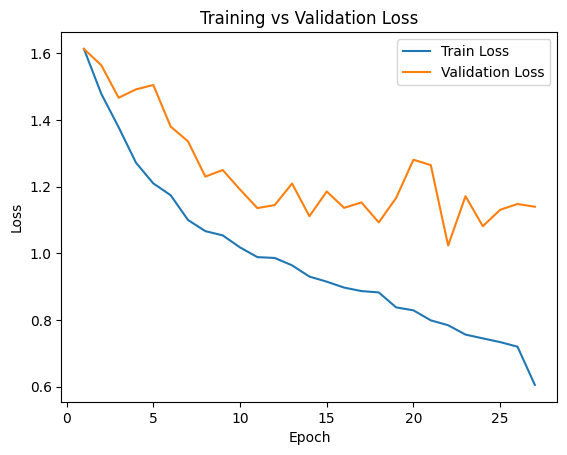

In [38]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## Testing

In [39]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)

        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == y).sum().item()
        test_total += y.size(0)

test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.6076


In [48]:
# -------------------
# COLLECT PREDICTIONS
# -------------------
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.numpy())

# Attach to dataframe
test_results = test_df.copy()
test_results["pred"] = all_preds
test_results["correct"] = test_results["pred"] == test_results["label"]

In [49]:
print("\nAccuracy by DATASET TYPE:")
type_acc = test_results.groupby("type")["correct"].mean()

for t, acc in type_acc.items():
    print(f"{t}: {acc:.4f}")


Accuracy by DATASET TYPE:
AudioWAV: 0.5973
EmoDB: 0.8434
Friends: 0.2698
RAVDESS: 0.6078
SAVEE: 0.5600
TESS: 1.0000
iPartment: 0.4950


In [50]:
print("\nAccuracy by SEX:")
sex_acc = test_results.groupby("sex")["correct"].mean()

for s, acc in sex_acc.items():
    print(f"{s}: {acc:.4f}")


Accuracy by SEX:
female: 0.7029
male: 0.6127


In [57]:
print("\nAccuracy by TYPE + EMOTION:")
type_sex_acc = test_results.groupby(["type", "emotion"])["correct"].mean()

for (t, s), acc in type_sex_acc.items():
    print(f"{t} - {s}: {acc:.4f}")


Accuracy by TYPE + EMOTION:
AudioWAV - ANG: 0.7253
AudioWAV - DIS: 0.5778
AudioWAV - FEA: 0.4915
AudioWAV - HAP: 0.4804
AudioWAV - NEU: 0.7848
AudioWAV - SAD: 0.5628
EmoDB - angry: 1.0000
EmoDB - disgust: 0.7500
EmoDB - fear: 0.7000
EmoDB - happy: 0.5556
EmoDB - neutral: 0.9412
EmoDB - sad: 0.7692
Friends - ANG: 0.1250
Friends - DIS: 0.0833
Friends - FEA: 0.2000
Friends - HAP: 0.4167
Friends - NEU: 0.5455
Friends - SAD: 0.2000
RAVDESS - angry: 0.7419
RAVDESS - disgust: 0.7083
RAVDESS - fear: 0.5758
RAVDESS - happy: 0.5600
RAVDESS - neutral: 0.6111
RAVDESS - sad: 0.4091
SAVEE - angry: 0.4286
SAVEE - disgust: 0.5000
SAVEE - fear: 0.3750
SAVEE - happy: 0.6667
SAVEE - neutral: 0.9333
SAVEE - sad: 0.1429
TESS - angry: 1.0000
TESS - disgust: 1.0000
TESS - fear: 1.0000
TESS - happy: 1.0000
TESS - neutral: 1.0000
TESS - sad: 1.0000
iPartment - ANG: 0.4737
iPartment - DIS: 0.0769
iPartment - FEA: 0.1667
iPartment - HAP: 0.5294
iPartment - NEU: 0.8333
iPartment - SAD: 0.0000


In [51]:
full_dataset = CREMAStressDataset(combined_df, audio_dir)
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False)

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for x, y in full_loader:
        x = x.to(device)
        outputs = model(x)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.numpy())

full_results = combined_df.copy()
full_results["pred"] = all_preds
full_results["correct"] = full_results["pred"] == full_results["label"]

full_acc = full_results["correct"].mean()
print(f"\nFull Dataset Accuracy: {full_acc:.4f}")


Full Dataset Accuracy: 0.7544


In [52]:
print("\n[Full Data] Accuracy by TYPE:")
print(full_results.groupby("type")["correct"].mean())

print("\n[Full Data] Accuracy by SEX:")
print(full_results.groupby("sex")["correct"].mean())


[Full Data] Accuracy by TYPE:
type
AudioWAV     0.681940
EmoDB        0.878855
Friends      0.450000
RAVDESS      0.766098
SAVEE        0.780952
TESS         0.999583
iPartment    0.723502
Name: correct, dtype: float64

[Full Data] Accuracy by SEX:
sex
female    0.776184
male      0.722362
Name: correct, dtype: float64


In [56]:
print("\n[Full Data] Accuracy by TYPE + EMOTION:")
print(full_results.groupby(["type", "emotion"])["correct"].mean())


[Full Data] Accuracy by TYPE + EMOTION:
type       emotion
AudioWAV   ANG        0.841857
           DIS        0.661684
           FEA        0.542093
           HAP        0.585366
           NEU        0.875805
           SAD        0.612903
EmoDB      angry      0.984252
           disgust    0.826087
           fear       0.855072
           happy      0.633803
           neutral    0.962025
           sad        0.903226
Friends    ANG        0.600000
           DIS        0.266667
           FEA        0.316667
           HAP        0.483333
           NEU        0.816667
           SAD        0.216667
RAVDESS    angry      0.802083
           disgust    0.911458
           fear       0.781250
           happy      0.812500
           neutral    0.822917
           sad        0.494792
SAVEE      angry      0.750000
           disgust    0.683333
           fear       0.783333
           happy      0.850000
           neutral    0.975000
           sad        0.450000
TESS      